In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
from xgboost import XGBClassifier
import shap
import joblib

os.makedirs('../models', exist_ok=True)
print('✅ Done')

✅ Done


In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [3]:
df.drop(columns=['customerID'], inplace=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling',
               'MultipleLines','OnlineSecurity','OnlineBackup',
               'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for col in binary_cols:
    df[col] = df[col].map({'Yes':1,'No':0,'No phone service':0,'No internet service':0})

df['gender'] = df['gender'].map({'Male':1,'Female':0})
df = pd.get_dummies(df, columns=['Contract','PaymentMethod','InternetService'], drop_first=False)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
print(f'✅ Clean shape: {df.shape}')

✅ Clean shape: (7043, 27)


In [4]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()
X_train_sc[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_sc[numeric_cols]  = scaler.transform(X_test[numeric_cols])
print(f'Train: {X_train_sc.shape[0]} | Test: {X_test_sc.shape[0]}')

Train: 5634 | Test: 1409


In [5]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8, scale_pos_weight=3, eval_metric='logloss', random_state=42),
}

results = []
trained = {}

for name, model in models.items():
    print(f'Training {name}...', end=' ')
    model.fit(X_train_sc, y_train)
    trained[name] = model
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    results.append({
        'Model': name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1 Score':  round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba), 4),
    })
    print(f"ROC-AUC = {results[-1]['ROC-AUC']}")

results_df = pd.DataFrame(results).set_index('Model')
results_df

Training Logistic Regression... ROC-AUC = 0.8417
Training Random Forest... ROC-AUC = 0.8417
Training XGBoost... ROC-AUC = 0.8365


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7374,0.5034,0.7834,0.6130,0.8417
Random Forest,0.7729,0.5553,0.7246,0.6288,0.8417
XGBoost,0.7530,0.5240,0.7594,0.6201,0.8365


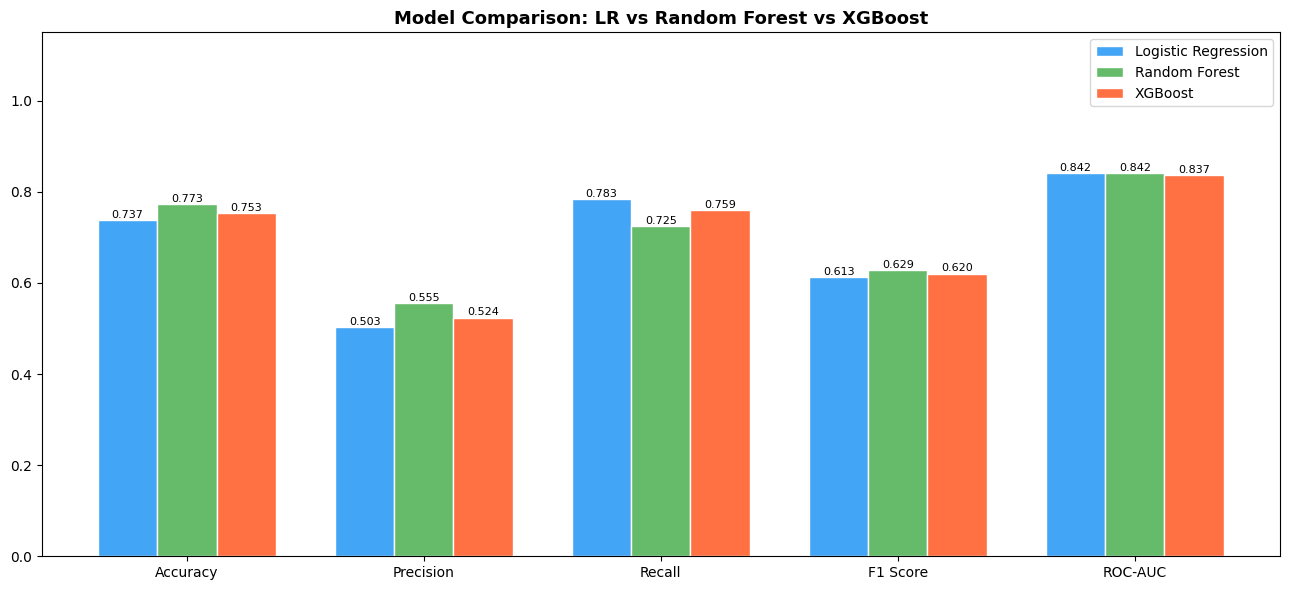

In [6]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25
colors = ['#42A5F5', '#66BB6A', '#FF7043']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (name, row) in enumerate(results_df.iterrows()):
    bars = ax.bar(x + i*width, [row[m] for m in metrics], width, label=name, color=colors[i], edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_title('Model Comparison: LR vs Random Forest vs XGBoost', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

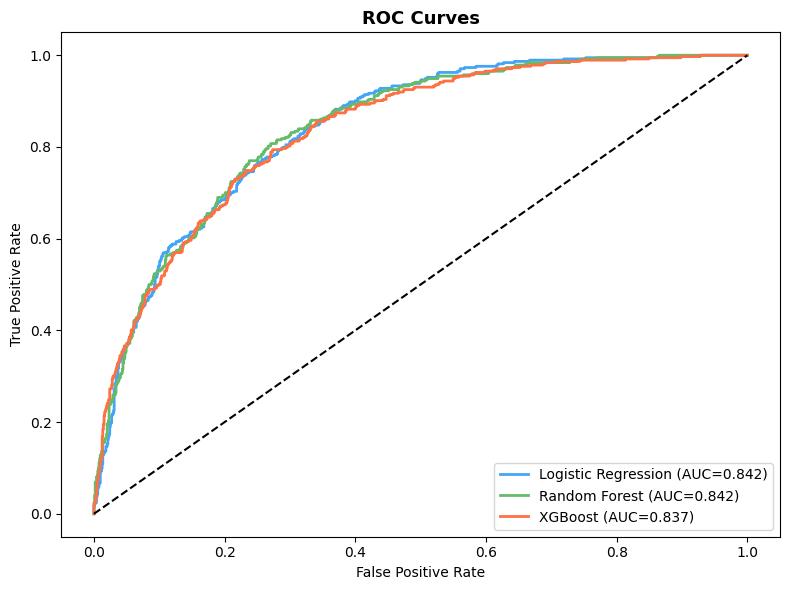

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
for (name, model), color in zip(trained.items(), colors):
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

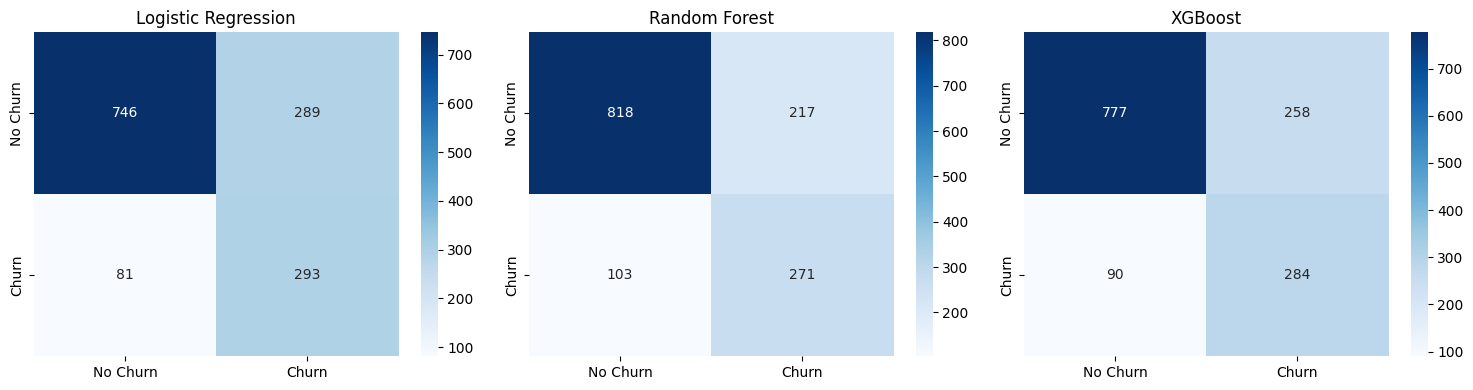

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, trained.items()):
    cm = confusion_matrix(y_test, model.predict(X_test_sc))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
    ax.set_title(name)
plt.tight_layout()
plt.show()

🏆 Best model: Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



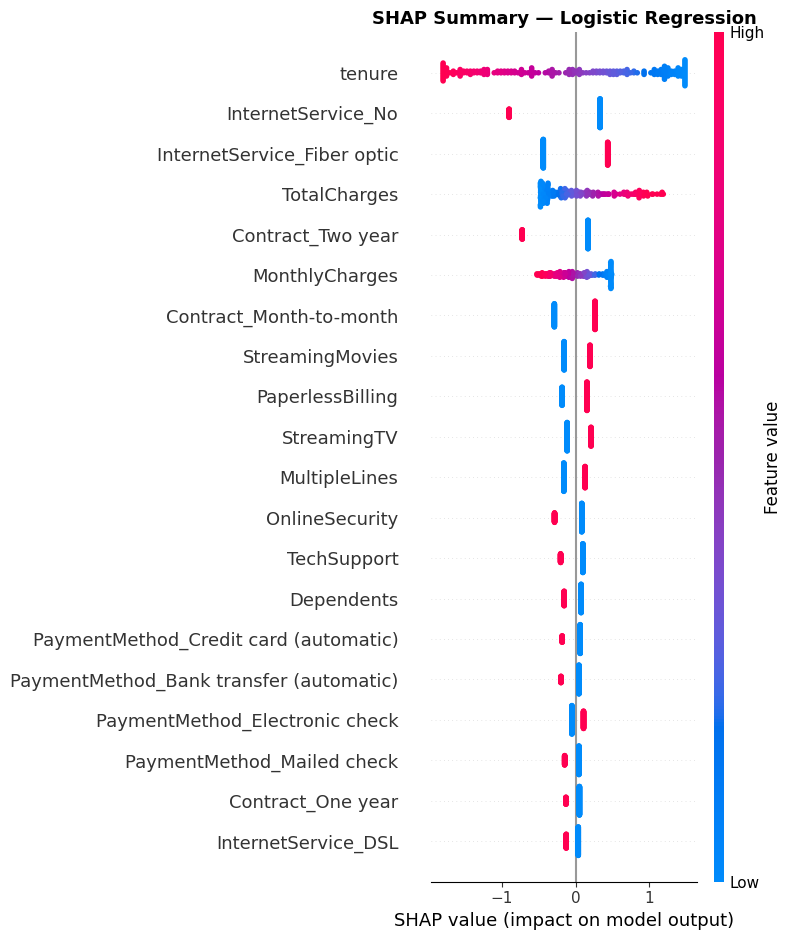

In [11]:
best_name  = results_df['ROC-AUC'].idxmax()
best_model = trained[best_name]
print(f'🏆 Best model: {best_name}')
print(classification_report(y_test, best_model.predict(X_test_sc), target_names=['No Churn','Churn']))

X_shap = X_test_sc.sample(n=200, random_state=42)

# Pick the right SHAP explainer based on model type
if best_name in ['Random Forest', 'XGBoost']:
    explainer = shap.TreeExplainer(best_model)
    shap_vals = explainer.shap_values(X_shap)
    sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals
else:
    # Logistic Regression → use LinearExplainer
    explainer = shap.LinearExplainer(best_model, X_train_sc)
    shap_vals = explainer.shap_values(X_shap)
    sv = shap_vals

plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_shap, plot_type='dot', show=False, max_display=20)
plt.title(f'SHAP Summary — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
joblib.dump(best_model,       '../models/best_model.pkl')
joblib.dump(scaler,           '../models/scaler.pkl')
joblib.dump(list(X.columns),  '../models/feature_names.pkl')
joblib.dump(best_name,        '../models/best_model_name.pkl')
print('💾 Models saved!')
for f in os.listdir('../models'):
    print(f'  {f}')

💾 Models saved!
  best_model.pkl
  best_model_name.pkl
  churn_model.pkl
  feature_columns.pkl
  feature_names.pkl
  scaler.pkl
